# Μετάπτωση του Spin

## Μετάπτωση Larmor

Σε αυτό το notebook θα δουμε τι συμβάνει στο spin του ηλεκτρονίου όταν εκτίθεται σε ένα ομοιογενές σταθερό μαγνητικό πεδίο, πως εφαρμόζουμε αλλαγή βάσης, πως χειριζόμαστε ορθοκανονικές καταστάσεις και διαγωνιοποιούμε τις Χαμιλτονιανές.

Η Χαμιλτονιανή σε ένα μαγνητικό δίπολο σε ομοιογενές μαγνητικό πεδίο δίνεται από τη σχέση:
$$H=-\vec{\mu}\cdot \vec{B}$$
Το μαγνητικό δίπολο του ηλεκτρονίου δίνεται από τη σχέση:
$$ \vec{\mu} = \gamma \vec{S}$$
όπου  $\gamma$ είναι ο γυρομαγνητικός λόγος του ηλεκτρονίου. Η ακριβής τιμή του $\gamma$ υπολογίζεται από την κβαντική θεωρία πεδίου και δίνεται κατά προσέγγιση από τη σχέση:
$$\gamma \approx 2\left( 1 + \frac{\alpha}{2\pi}\right)$$
όπου $\alpha$ είναι η σταθερά λεπτής υφής, $\alpha \approx 1/137$.  Το διάνυσμα του σπιν δίνεται από τους πίνακες Pauli,

$$ \vec{S} = \frac{\hbar}{2}\vec{\sigma}$$
Επομένως η Χαμιλτονιανή για το spin του ηλεκτρονίου σε μαγνητικό πεδίο είναι:
$$ H = -\gamma \frac{\hbar}{2}\sum_i \sigma_i B_i$$
όπου $i=x,y,z$.

Σε αυτό το notebook, υποθέτουμε ότι $\hbar=1$ and $|B|=3T$.

### Αναφορές

Larmor Precession, Griffiths, Chapter 4, page 178

Changing Bases, Griffiths, Appendix A.4

Pauli matrices, https://en.wikipedia.org/wiki/Pauli_matrices

Scipy "eigh" function, https://docs.scipy.org/doc/numpy/reference/generated/numpy.linalg.eigh.html#numpy.linalg.eigh





### Προγραμματίζοντας τη Χαμιλτονιανή
Φορτώνουμε της βιβλιοθήκες και θέτουμε $ | B | = 3Τ $.

In [1]:
%matplotlib ipympl
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button, RadioButtons
import numpy as np
import numpy.linalg
import math

In [2]:
B=3 # [T]: Uniform magnetic field
alpha = 1./137 # Fine structure constant
g = 2*(1+alpha/(2*np.pi)) # [s−1⋅T−1]: Gyromagnetic ratio
hbar = 1   # Planck's Constant

#### Ερώτηση 1
Ας υποθέσουμε ότι το διάνυσμα του μαγνητικού πεδίου βρίσκεται στο επίπεδο Y-Z και ότι σχηματίζει γωνία $\theta$ με τον άξονα z.  Συμπληρώστε αυτές τις τρεις συναρτήσεις για να επιστρέψετε τους πίνακες Pauli, το διάνυσμα μαγνητικού πεδίου και τη Χαμιλτονιανή. Για να ελέγξετε την εργασία σας, βεβαιωθείτε ότι η Χαμιλτονιανή που υπολογίζεται για $ |B| = 3Τ $ και $\theta = \pi/4 $ είναι σωστή.

Οι πίνακες Pauli είναι:
$$\sigma_x = \begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix}, \quad
\sigma_y = \begin{pmatrix} 0 & -i \\ i & 0 \end{pmatrix}, \quad
\sigma_z = \begin{pmatrix} 1 & 0 \\ 0 & -1 \end{pmatrix} $$

Εφόσον το μαγνητικό πεδίο είναι πάνω στον yz-επίπεδο, η x-συνιστώσα του είναι μηδενική:
$$B_x = 0$$
Το μαγνητικό πεδίο σχηματίζει γωνία θ με τον άξονα z, άρα:
$$B_z = |B|\cos\theta \quad \text{και} \quad B_y = |B|\sin\theta$$

In [3]:
# Defining the Pauli matrices
def pauli_matrices():
    sig_x = np.matrix([[0, 1], [1, 0]])
    sig_y = np.matrix([[0, -1j], [1j, 0]])
    sig_z = np.matrix([[1, 0], [0, -1]])

    # Collecting all the σ-matrices in a single matrix
    sigmas = np.array([sig_x, sig_y, sig_z])
    return sigmas

# Printing the shape of the output of the function for the pauli matrices
print(f"Shape of the Pauli matrices function output: {pauli_matrices().shape}\n")


# Defining a magnetic field on the yz-plane
def magnetic_field(theta, B):
    return np.array([0, B * np.sin(theta), B * np.cos(theta)])

# Defining the problem Hamiltonian H=-γ(ℏ/2)σ⋅B=-γ(ℏ/2)(σx⋅Bx+σy⋅By+σz⋅Bz)
def Hamiltonian(theta, B):
    sigmas = pauli_matrices()
    B_vector = magnetic_field(theta, B)
    # I want to multiply the σ-matrices with the corresponding component of the magnetic field.
    # For the sigmas it is the first dimension (3 for the 3 matrices) and for the B its only dimension
    H = - g * (hbar/2) * np.tensordot(sigmas, B_vector, axes=([0], [0]))
    return H

# Testing the Hamiltonian function
theta_check = np.pi / 4
print("Hamiltonian Matrix for θ=π/4:")
print(f"H=\n {Hamiltonian(theta_check, B).round(4)}")

Shape of the Pauli matrices function output: (3, 2, 2)

Hamiltonian Matrix for θ=π/4:
H=
 [[-2.1238+0.j      0.    +2.1238j]
 [-0.    -2.1238j  2.1238-0.j    ]]


## Διαγωνιοποίηση της Hamiltonian
Οι πίνακες Pauli είναι συνήθως ως προς τη βάση $S_Z$, οπότε η παραπάνω Χαμιλτονιανή δεν θα είναι διαγώνια εάν το μαγνητικό πεδίο δεν είναι κατά μήκος του άξονα z. Προκειμένου να βρούμε τις ιδιοενέργειες και τις ιδιοκαταστάσεις για το ηλεκτρόνιο στο μαγνητικό πεδίο, μπορούμε να χρησιμοποιήσουμε την ["eigh" συνάρτηση της Scipy](https://docs.scipy.org/doc/numpy/reference/generated/numpy.linalg.eigh.html#numpy.linalg.eigh).
#### Ερώτηση 2
Χρησιμοποιήστε την "eigh" για να βρείτε τις ενέργειες και τις ιδιοκαταστάσεις για $\theta = \pi/3 $ και $ | Β | = 3Τ $.  Οι ιδιοσυναρτήσεις επιστρέφονται σε ένα πίνακα, $\Psi $, όπου κάθε στήλη είναι μια ιδιοκατάσταση. Οι ιδιοσυναρτήσεις πρέπει να είναι ορθογώνιες, έτσι ώστε $ \Psi^\dagger \Psi = Ι $.  Ελέγξτε ότι αυτό ισχύει.

Πιο αναλυτικά η παραπάνω μεθοδολογία:

Ο πίνακας $\Psi$ είναι: $\Psi = \begin{pmatrix} \lvert \psi_1 \rangle & \lvert \psi_2 \rangle \end{pmatrix}$, όπου: $\lvert \psi_1 \rangle = \begin{pmatrix} \psi_{11} \\ \psi_{12} \end{pmatrix}, \quad \lvert \psi_2 \rangle = \begin{pmatrix} \psi_{21} \\ \psi_{22} \end{pmatrix}$

Άρα, το γινόμενο $ \Psi^\dagger \Psi $ είναι:
$$\Psi^\dagger \Psi = \begin{pmatrix} \lvert \psi_1 \rangle & \lvert \psi_2 \rangle \end{pmatrix}^\dagger \begin{pmatrix} \lvert \psi_1 \rangle & \lvert \psi_2 \rangle \end{pmatrix}
= \begin{pmatrix} \lvert \psi_1 \rangle^\dagger \\ \lvert \psi_2 \rangle^\dagger \end{pmatrix}
\begin{pmatrix} \lvert \psi_1 \rangle & \lvert \psi_2 \rangle \end{pmatrix}
= \begin{pmatrix} \langle \psi_1 \rvert \\ \langle \psi_2 \rvert \end{pmatrix}
\begin{pmatrix} \lvert \psi_1 \rangle & \lvert \psi_2 \rangle \end{pmatrix}
= \begin{pmatrix}
\langle \psi_1 \lvert \psi_1 \rangle & \langle \psi_1 \lvert \psi_2 \rangle \\ \langle \psi_2 \lvert \psi_1 \rangle & \langle \psi_2 \lvert \psi_2 \rangle
\end{pmatrix}
= \begin{pmatrix}
1 & 0 \\ 0 & 1
\end{pmatrix} = \mathbf{I} $$

αφού από την κανονικοποίηση:$ \langle \psi_i \lvert \psi_j \rangle = \delta_{ij} $

Αν και η παραπάνω γραφή είναι βοηθητική για τη θεωρητική μελέτη, δεν παρουσιάζει αρκετά καλά τι συμβαίνει στην υπολογιστική επεξεργασία.

Γράφω τον πίνακα $ \Psi $ στην πλήρη μορφή του (όπου η κάθε στήλη είναι μια ιδιοκατάσταση):

$$ \Psi = \begin{pmatrix} \psi_{11} & \psi_{21} \\ \psi_{12} & \psi_{22} \end{pmatrix}$$

Τότε:
$$ \Psi^\dagger \Psi = \begin{pmatrix} \psi_{11}^* & \psi_{12}^* \\ \psi_{21}^* & \psi_{22}^* \end{pmatrix} \begin{pmatrix} \psi_{11} & \psi_{21} \\ \psi_{12} & \psi_{22} \end{pmatrix} = \begin{pmatrix} \psi_{11}^*\psi_{11} + \psi_{12}^*\psi_{12} & \psi_{11}^*\psi_{21} + \psi_{12}^*\psi_{22} \\ \psi_{21}^*\psi_{11} + \psi_{22}^*\psi_{12} & \psi_{21}^*\psi_{21} + \psi_{22}^*\psi_{22} \end{pmatrix}
= \begin{pmatrix} \lVert \psi_1 \rVert^2 & \langle \psi_1 \lvert \psi_2 \rangle \\ \langle \psi_2 \lvert \psi_1 \rangle & \lVert \psi_2 \rVert^2  \end{pmatrix}
= \begin{pmatrix} 1 & 0 \\ 0 & 1\end{pmatrix} = \mathbf{I}$$

In [4]:
print("Problem for θ=π/3:")
print("-"*20)
# Defining the Hamiltonian for θ=π/3 and the defined B
H = Hamiltonian(np.pi/3, B)
print("Hamiltonian Matrix:")
print(f"H=\n{H.round(4)}")

# Solving the eigenvalue problem automatically with Python
(energies, eigenstates) = np.linalg.eigh(H)

print(f"\n{'Eigenenergies (E)':^17} | {'Eigenstates (ψi)':^25}")
print("-"*45)
for i in range(len(energies)): # Each eigenstate is a column
  print(f"{energies[i]:^17.4f} | {np.array2string(eigenstates[:, i], precision=4):<25}")

print("\nΨ Matrix (each eigenstate a column):")
print(f"Psi=\n {eigenstates.round(4)}")

# Testing the result with the identity Ψ†Ψ=Ι
# The hemit conjugate is the result after the conjugate and the transposition
print("\nChecking the identity Ψ†Ψ=I")
print("Psi.conj.T*Psi=\n", np.dot(eigenstates.conj().T, eigenstates))


Problem for θ=π/3:
--------------------
Hamiltonian Matrix:
H=
[[-1.5017+0.j      0.    +2.6011j]
 [-0.    -2.6011j  1.5017-0.j    ]]

Eigenenergies (E) |     Eigenstates (ψi)     
---------------------------------------------
     -3.0035      | [-0.866-0.j   0.   -0.5j]
     3.0035       | [-0.5+0.j     0. +0.866j]

Ψ Matrix (each eigenstate a column):
Psi=
 [[-0.866-0.j    -0.5  +0.j   ]
 [ 0.   -0.5j    0.   +0.866j]]

Checking the identity Ψ†Ψ=I
Psi.conj.T*Psi=
 [[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]


Κάθε ιδιοκατάσταση υπακούει στην χρονικά ανεξάρτητη εξίσωση Schrodinger.
$$ Η \psi_i = Ε_i \psi_i $$
Σε αυτή την εξίσωση η $Ε$ είναι μια βαθμωτή τιμή.  Θα μπορούσαμε να γράψουμε αυτήν την εξίσωση για κάθε ιδιοκατάσταση, αλλά υπάρχει ένας πιο ωραίος τρόπος για να την εκφράσουμε σαν μια εξίσωση πινάκων, με τον προηγούμενο πίνακα ιδιοκαταστάσεων $ \Psi $.
$$ Η \Psi = \Psi Ε $$
Όπου τώρα $Ε$ είναι ένας διαγώνιος πίνακας όπου ένα στοιχείο $ Ε (i, i) $ είναι η ενέργεια της $i$ ιδιοκατάστασης. Πάνω, δείξαμε ότι $ \Psi^\dagger \Psi = Ι $, που σημαίνει ότι $ \Psi^\dagger = \Psi^{-1}$.  Επομένως
$$\Psi^{-1}Η\Psi = \Psi^{\dagger}Η\Psi = \Psi^{\dagger}\Psi Ε= Ε$$
Έτσι ο $\Psi$ είναι ο πίνακας μετασχηματισμού της Hamiltonian!
#### Ερώτηση 3
Ελέγξτε  ότι $\Psi^{\dagger} Η \Psi = Ε$ μας δίνει διαγώνιο πίνακα.

In [5]:
# Performing the Hamiltonian diagonization transformation Ψ†HΨ
E_matrix = eigenstates.conj().T @ H @ eigenstates # @ operator for matrix multiplication
# Alternative: With dot product in two steps
# step1 = np.dot(eigenstates.conj().T, H)
# E_matrix = np.dot(step1, eigenstates)
print(f"E=Ψ†HΨ=\n {E_matrix.round(4)}")

E=Ψ†HΨ=
 [[-3.0035+0.j  0.    +0.j]
 [ 0.    +0.j  3.0035+0.j]]


## Χρόνος εξέλιξης των πιθανοτήτων
Ας υποθέσουμε ότι στο $ t = 0 $, το ηλεκτρόνιο μετράται  να έχει $ s_z = \hbar/2 $, έτσι ώστε η κατάσταση να είναι $ \chi (0) = | \uparrow>_z $. Στη βάση  z
$$\chi(0)_z = \left( \begin{array}{ccc}
1 \\
0  \end{array} \right)_z=1*|\uparrow>_z+0*|\downarrow>_z$$

Ωστόσο, θα μπορούσαμε επίσης να γράψουμε τις καταστάσεις στη βάση των ιδιοδιανυσμάτων, όπου η κατάσταση spin-up σημαίνει ότο το spin προσανατολίζεται κατά μήκος της κατεύθυνσης του μαγνητικού πεδίου, όπου
$$\chi(0)_B = \left( \begin{array}{ccc}
a \\
b  \end{array} \right)_B =a*|\uparrow>_B+b*|\downarrow>_B$$
and $a^2+b^2=1$.  


Πώς πηγαίνουμε από τη μια βάση στο άλλη;  Μετατρέπουμε  την κατάσταση με τον ίδιο πίνακα μετασχηματισμού που χρησιμοποιήσαμε για τη Hamiltonian, το πίνακα των ιδιοδιανυσμάτων.
$$ \chi(0)_B = \Psi^\dagger \chi(0)_z$$

#### Ερώτηση 4
Δεδομένου ότι $\chi(0)=|\uparrow>_z$, ποια ειναι η $ \chi (0) $ στη βάση Β αν $ \theta = \pi/5 $;


In [6]:
print("Problem for θ=π/5:")
print("-"*20)
# Defining the Hamiltonian for θ=π/3 and the defined B
H = Hamiltonian(np.pi/5, B)

# # Solving the eigenvalue problem automatically with Python
(energies, eigenstates) = np.linalg.eigh(H)

# Transforming the eigenstate from the z-basis to the B-basis
psi_0_zbasis = np.matrix([[1],[0]])
psi_0_Bbasis = np.dot(eigenstates.conj().T, psi_0_zbasis) #χB(0)=Ψ†χz(0)
print(f"chi(0)_z=\n {psi_0_zbasis.round(4)}")
print(f"chi(0)_B=\n {psi_0_Bbasis.round(4)}")

Problem for θ=π/5:
--------------------
chi(0)_z=
 [[1]
 [0]]
chi(0)_B=
 [[-0.9511+0.j]
 [-0.309 +0.j]]


Τώρα που έχουμε την αρχική κατάσταση στη βάση Β, τη βάση των ιδιοκαταστάσεων, μπορούμε εύκολα να βρούμε την εξέλιξη της κατάστασης.
$$\chi(t)_B = \left( \begin{array}{ccc}
a*e^{-iE_\uparrow t/\hbar} \\
b*e^{-iE_\downarrow t/\hbar}  \end{array} \right)_B =a*e^{-iE_\uparrow t/\hbar}|\uparrow>_B+b*e^{-iE_\downarrow t/\hbar}|\downarrow>_B$$
και $a^2+b^2=1$.  

#### Ερώτηση 5
Γράψτε μια συνάρτηση για να υπολογίσετε το $\chi (t)_B $ από το $\chi(0)_B$, τις ιδιοενέργειες και το χρόνο.  Εκτυπώστε το $\chi(t = 5)_B$ για $\theta = \pi/3 $.

In [7]:
print("Problem for θ=π/3:")
print("-"*20)

#Defining the problem Hamiltonian
H = Hamiltonian(np.pi/3, B)
print(f"Hamiltonian H=\n {H.round(4)}")

# Solving the eigenvalue problem
(energies, eigenstates) = np.linalg.eigh(H)
psi_0_zbasis = np.matrix([[1],[0]])
psi_0_Bbasis = eigenstates.conj().T @ psi_0_zbasis #χB(0)=Ψ†χz(0)

# Finding the time evolution
def get_psi_t_Bbasis(energies, psi_0_Bbasis, time):
    psi_t_Bbasis = np.matrix(np.zeros_like(psi_0_Bbasis))
    for i in range(0, len(energies)):
        psi_t_Bbasis[i, 0] = psi_0_Bbasis[i,0] * np.exp(-1j * energies[i] * time / hbar)
    return psi_t_Bbasis

print(f"\nState chi(t=5)_B=\n {get_psi_t_Bbasis(energies, psi_0_Bbasis, 5).round(4)}")

Problem for θ=π/3:
--------------------
Hamiltonian H=
 [[-1.5017+0.j      0.    +2.6011j]
 [-0.    -2.6011j  1.5017-0.j    ]]

State chi(t=5)_B=
 [[0.6676-0.5516j]
 [0.3855+0.3185j]]


Η πιθανότητα στο χρόνο $ t $  της μέτρηση του ηλεκτρονίου να έχει spin up στην κατεύθυνση z είναι
$$ P(S_z=\hbar/2, t) = |<\chi(0)_B|\chi(t)_B>|^2$$
#### Ερώτηση 6
Κάντε ένα γράφημα $P(S_z=\hbar/2, t)$ για $t=0...3$ και για  $\theta = \pi/2, \pi/4, \pi/6$.

Πιο αναλυτικά η μεθοδολογία για την πιθανότητα:

Τη χρονική στιγμή t που πραγματοποιείται η μέτρηση το σύστημα βρίσκεται στην κατάσταση  $ \lvert \chi(t) \rangle_z $.

Επειδή ζητάμε το spin του ηλεκτρονίου στην κατεύθυνση z να είναι spin up, ζητάμε το σύστημα να βρεθεί στην κατάσταση $ \lvert \uparrow \rangle_z $.

Η πιθανότητα το σύστημα από την $ \lvert \chi(t) \rangle_z $ να βρεθεί στην $ \lvert \uparrow \rangle_z $ είναι:
$$P(S_z=\frac{\hbar}{2}, t)=\lvert _z\langle \uparrow \lvert \chi(t) \rangle _z \rvert ^2$$

Όμως, η πιθανότητα είναι ακόμη στη z-βάση. Χρησιμοποιώντας την ταυτότητα $\Psi^\dagger \Psi = \Psi \Psi^\dagger = Ι$ και λαμβάνοντας υπόψη την μετατροπή στη B-βάση:
$ \lvert \uparrow \rangle_B = \Psi^\dagger \lvert \uparrow \rangle_z $ και $ \lvert \chi(t) \rangle_B = \Psi^\dagger \lvert \chi(t) \rangle_z$, η πιθανότητα μπορεί να γραφεί ως:

$$P(S_z=\frac{\hbar}{2}, t)=\lvert _z\langle \uparrow \mid \chi(t) \rangle _z \rvert ^2
= \lvert _z\langle \uparrow \rvert \quad Ι \quad \lvert  \chi(t) \rangle _z \rvert ^2
= \lvert _z\langle \uparrow \rvert \quad \Psi \Psi^\dagger \quad \lvert  \chi(t) \rangle _z \rvert ^2
= \lvert (\Psi^\dagger \lvert \uparrow \rangle_z)^\dagger(\Psi^\dagger \lvert \chi(t) \rangle_z) \rvert ^2
=\lvert (\lvert \uparrow \rangle_B)^\dagger(\lvert \chi(t) \rangle_B) \rvert ^2
=\lvert _B\langle \uparrow \lvert \chi(t) \rangle _B \rvert ^2$$

Στο συγκεκριμένο πρόβλημα έχουμε θεωρήσει ότι το σύστημα τη χρονική στιγμή $ t=0 $ βρίσκεται στην κατάσταση spin-up, δηλαδή $ \lvert \uparrow \rangle_B = \lvert \chi(0)_B \rangle $. Έτσι, προκύπτει το προηγούμενο συμπέρασμα:
$$P(S_z=\frac{\hbar}{2}, t)=\lvert _B\langle \uparrow \lvert \chi(t) \rangle _B \rvert ^2 = \lvert \langle \chi(0)_B \lvert \chi(t)_B \rangle \rvert ^2$$

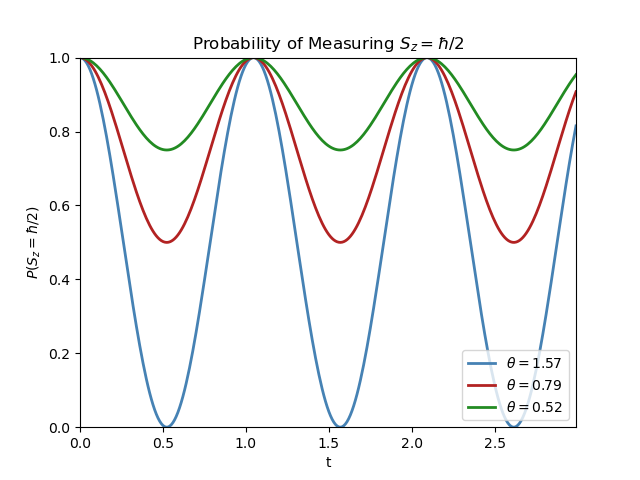

In [8]:
t = np.arange(0,3,0.01)
thetas = [np.pi/2, np.pi/4, np.pi/6]
colors = ['steelblue','firebrick','forestgreen']

plt.figure()
for k in range(0, len(thetas)):
  # Choosing a theta
  theta = thetas[k]
  # Solving the eigenvalue problem
  (energies, eigenstates) = np.linalg.eigh( Hamiltonian(theta, B) )
  # Basis transform z → B
  prob_sz_up = np.zeros_like(t)
  psi_0_zbasis = np.matrix([[1],[0]])
  psi_0_Bbasis = np.dot( eigenstates.conj().T, psi_0_zbasis )
  for i in range(0, len(t)):
      psi_t_Bbasis = get_psi_t_Bbasis(energies, psi_0_Bbasis, t[i])
      # Bra-ket/Inner Product <χ(0)|χ(t)>, where <χ(0)|=(|χ(0)>)†
      overlap = np.dot(psi_0_Bbasis.conj().T, psi_t_Bbasis)[0,0]
      # Modulus of the bra-ket
      prob_sz_up[i] = (np.conjugate(overlap)*overlap).real
  plt.plot(t, prob_sz_up, color=colors[k], lw=2, label=r'$\theta=$'+str("%.2f" %theta))

plt.xlabel("t")
plt.ylabel(r"$P(S_z=\hbar/2)$")
plt.title(r"Probability of Measuring $S_z=\hbar/2$")
plt.legend()
plt.xlim(min(t), max(t))
plt.ylim([0,1])
plt.savefig("ProbSzUp_Solution.png")
plt.show()